In [ ]:
!pip install -q kagglehub nltk wordcloud

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "amananandrai/ag-news-classification-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 11.4M/11.4M [00:01<00:00, 6.29MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2


In [ ]:
print(os.listdir(path))

['train.csv', 'test.csv']


In [ ]:
train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (120000, 3)
Testing shape: (7600, 3)


In [ ]:
print("Training columns:")
print(train_df.columns)

print("\nFirst 5 rows:")
display(train_df.head())

Training columns:
Index(['Class Index', 'Title', 'Description'], dtype='object')

First 5 rows:


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [ ]:
train_df.columns = ['label', 'title', 'description']
test_df.columns = ['label', 'title', 'description']

In [ ]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
label          0
title          0
description    0
dtype: int64

Missing values in testing data:
label          0
title          0
description    0
dtype: int64


In [ ]:
class_names = {
    1: 'World',
    2: 'Sports',
    3: 'Business',
    4: 'Science'
}

train_df['category'] = train_df['label'].map(class_names)

test_df['category'] = test_df['label'].map(class_names)

train_df.head()

,label,title,description,category
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business


In [ ]:
print(
    train_df['category'].value_counts()
)

category
Business    30000
Science     30000
Sports      30000
World       30000
Name: count, dtype: int64


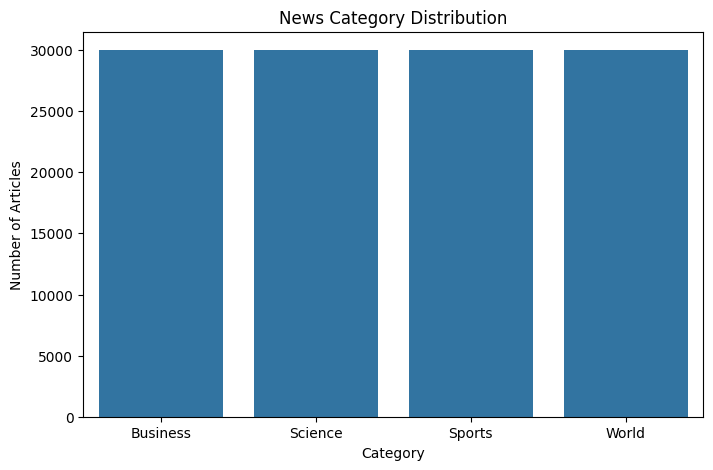

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x='category'
)

plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

plt.show()

In [ ]:
train_df['text'] = (
    train_df['title'].fillna('') + ' ' +
    train_df['description'].fillna('')
)

test_df['text'] = (
    test_df['title'].fillna('') + ' ' +
    test_df['description'].fillna('')
)

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Keep only letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [ ]:
train_df['clean_text'] = train_df['text'].apply(clean_text)

test_df['clean_text'] = test_df['text'].apply(clean_text)

In [ ]:
display(
    train_df[
        ['text', 'clean_text', 'category']
    ].head()
)

,text,clean_text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bear claw back black reuters reuters s...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...,Business
4,"Oil prices soar to all-time record, posing new...",oil price soar time record posing new menace u...,Business


In [ ]:
X = train_df['clean_text']
y = train_df['label']

print("Number of samples:", len(X))
print("Number of classes:", y.nunique())

Number of samples: 120000
Number of classes: 4


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

Training: 96000
Validation: 24000


In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

Training TF-IDF shape: (96000, 50000)
Validation TF-IDF shape: (24000, 50000)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    multi_class='auto'
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto')

In [ ]:
y_pred = logistic_model.predict(
    X_val_tfidf
)

In [ ]:
accuracy = accuracy_score(
    y_val,
    y_pred
)

print(
    f"Validation Accuracy: {accuracy:.4f}"
)

print(
    f"Validation Accuracy: {accuracy * 100:.2f}%"
)

Validation Accuracy: 0.9223
Validation Accuracy: 92.23%


In [ ]:
print(
    classification_report(
        y_val,
        y_pred,
        target_names=[
            'World',
            'Sports',
            'Business',
            'Science'
        ]
    )
)

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.89      0.90      0.90      6000
     Science       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



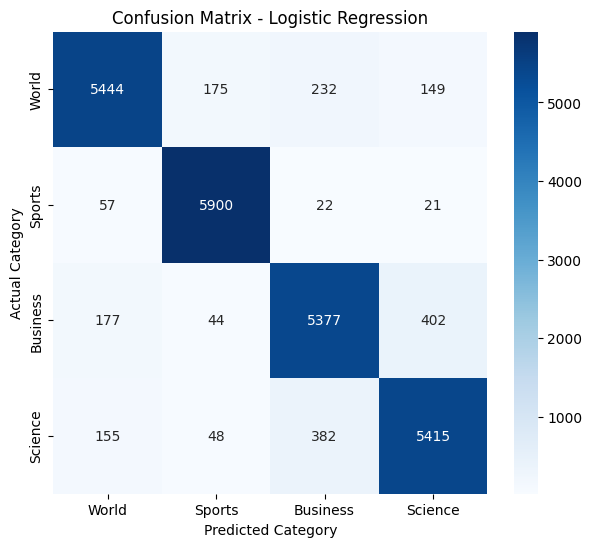

In [ ]:
cm = confusion_matrix(
    y_val,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'World',
        'Sports',
        'Business',
        'Science'
    ],
    yticklabels=[
        'World',
        'Sports',
        'Business',
        'Science'
    ]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

In [ ]:
def predict_category(news):

    cleaned = clean_text(news)

    vector = tfidf.transform([cleaned])

    prediction = logistic_model.predict(vector)[0]

    return class_names[prediction]

In [ ]:
news_samples = [
    "The football team won the championship after an exciting final match.",

    "The company reported strong financial results and increased profits.",

    "Scientists discovered a new technology that could improve artificial intelligence.",

    "The president met with international leaders to discuss global issues."
]

for news in news_samples:

    print("News:")
    print(news)

    print("Predicted Category:",
          predict_category(news))

    print("-" * 80)

News:
The football team won the championship after an exciting final match.
Predicted Category: Sports
--------------------------------------------------------------------------------
News:
The company reported strong financial results and increased profits.
Predicted Category: Business
--------------------------------------------------------------------------------
News:
Scientists discovered a new technology that could improve artificial intelligence.
Predicted Category: Science
--------------------------------------------------------------------------------
News:
The president met with international leaders to discuss global issues.
Predicted Category: World
--------------------------------------------------------------------------------


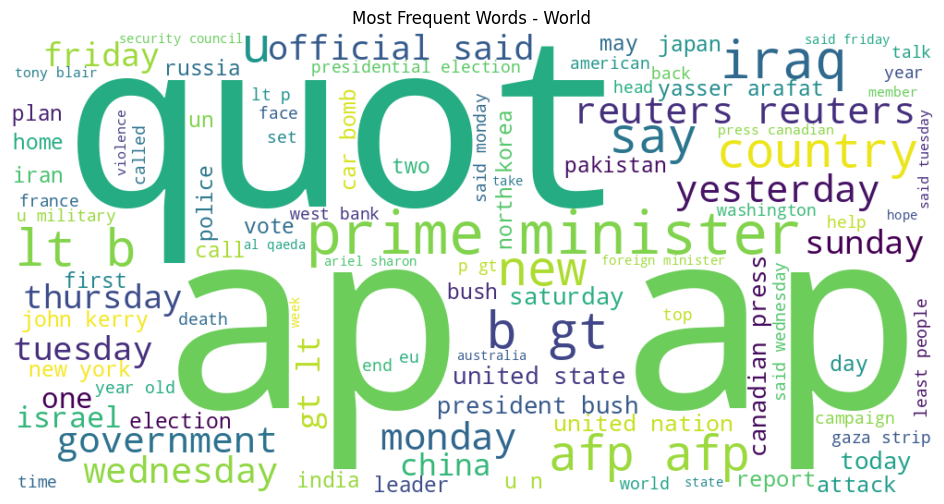

In [ ]:
world_text = ' '.join(
    train_df[
        train_df['category'] == 'World'
    ]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(world_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title("Most Frequent Words - World")

plt.show()

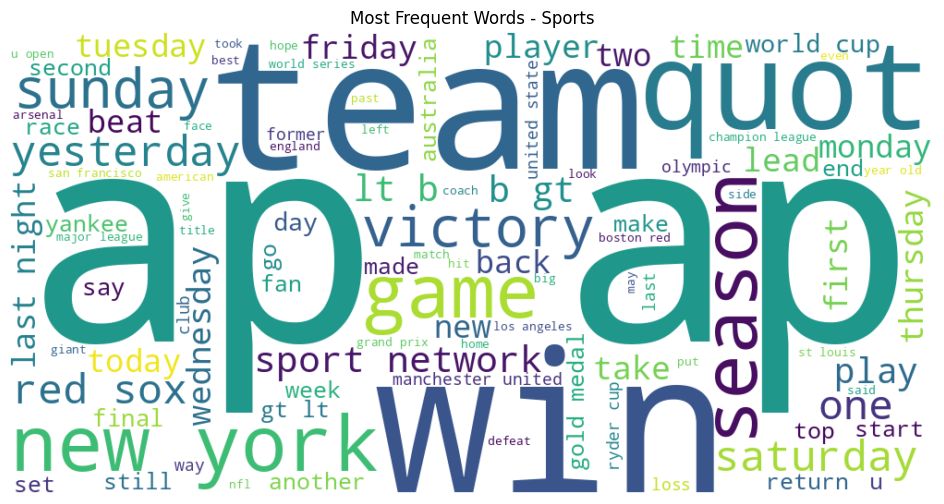

In [ ]:
sports_text = ' '.join(
    train_df[
        train_df['category'] == 'Sports'
    ]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(sports_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title("Most Frequent Words - Sports")

plt.show()

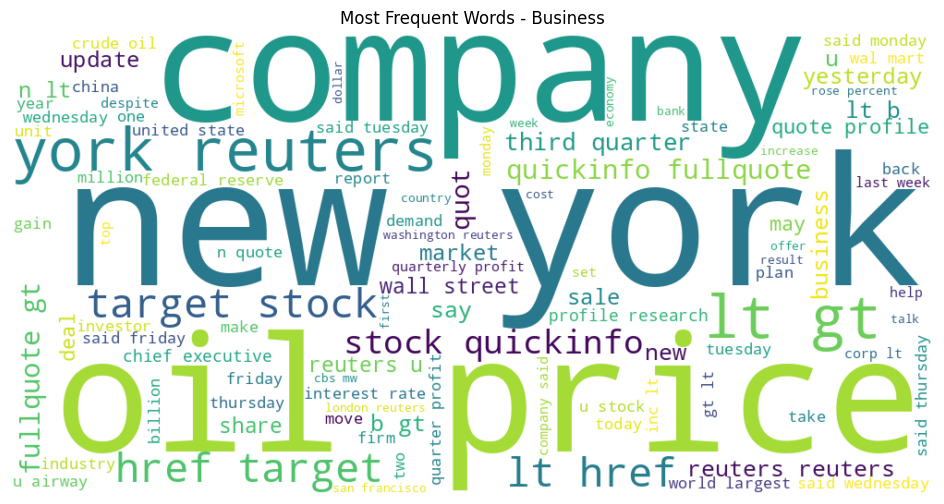

In [ ]:
business_text = ' '.join(
    train_df[
        train_df['category'] == 'Business'
    ]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(business_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title("Most Frequent Words - Business")

plt.show()

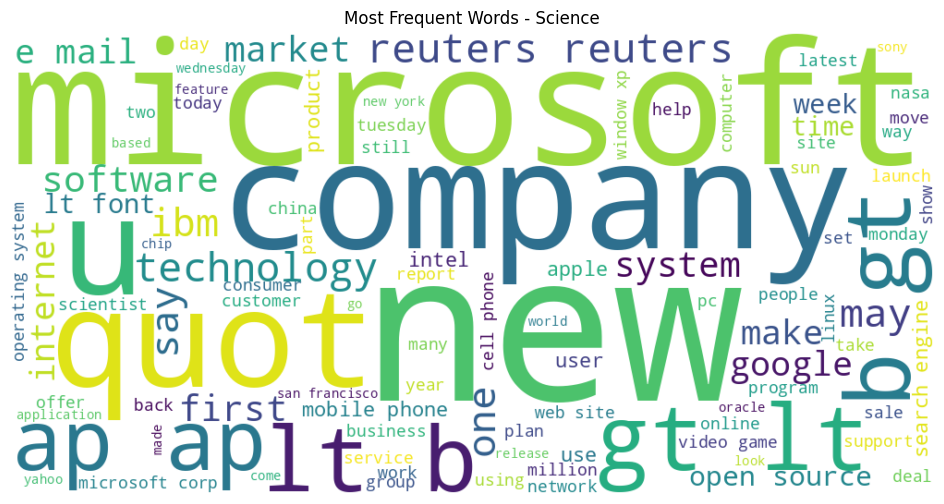

In [ ]:
science_text = ' '.join(
    train_df[
        train_df['category'] == 'Science'
    ]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(science_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title("Most Frequent Words - Science")

plt.show()

In [ ]:
NN_SAMPLES = 5000

X_nn = X_train_tfidf[:NN_SAMPLES]
y_nn = y_train.iloc[:NN_SAMPLES]

# Also limit validation samples to avoid memory issues for dense conversion
X_nn_val = X_val_tfidf[:NN_SAMPLES]
y_nn_val = y_val.iloc[:NN_SAMPLES]

print("NN training shape:", X_nn.shape)
print("NN validation shape:", X_nn_val.shape)

NN training shape: (30000, 50000)
NN validation shape: (24000, 50000)


In [ ]:
print("NN training shape:", X_nn.shape)
print("NN validation shape:", X_nn_val.shape)

NN training shape: (30000, 50000)
NN validation shape: (24000, 50000)


In [ ]:
y_nn_zero = y_nn - 1
y_nn_val_zero = y_nn_val - 1

In [ ]:
nn_model = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_nn.shape[1],)
    ),

    Dropout(0.5),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        4,
        activation='softmax'
    )
])

nn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     6,400,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,408,644 (24.45 MB)

 Trainable params: 6,408,644 (24.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = nn_model.fit(
    X_nn,
    y_nn_zero,
    validation_data=(
        X_nn_val,
        y_nn_val_zero
    ),
    epochs=10,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=2
)

Epoch 1/10
235/235 - 313s - 1s/step - accuracy: 0.8329 - loss: 0.5902 - val_accuracy: 0.9165 - val_loss: 0.2627
Epoch 2/10
235/235 - 154s - 657ms/step - accuracy: 0.9433 - loss: 0.1856 - val_accuracy: 0.9145 - val_loss: 0.2633
Epoch 3/10
235/235 - 79s - 335ms/step - accuracy: 0.9734 - loss: 0.0901 - val_accuracy: 0.9129 - val_loss: 0.2969


In [ ]:
nn_loss, nn_accuracy = nn_model.evaluate(
    X_nn_val,
    y_nn_val_zero,
    verbose=0
)

print(
    f"Neural Network Accuracy: {nn_accuracy:.4f}"
)

print(
    f"Neural Network Accuracy: {nn_accuracy * 100:.2f}%"
)

Neural Network Accuracy: 0.9165
Neural Network Accuracy: 91.65%


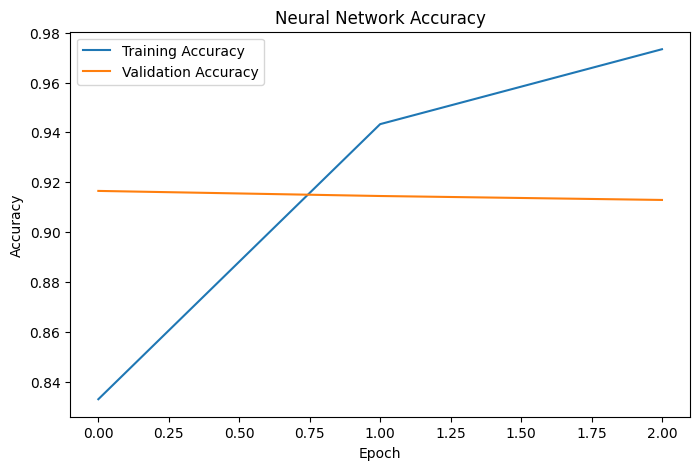

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Neural Network Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Neural Network'
    ],

    'Accuracy': [
        accuracy,
        nn_accuracy
    ]
})

comparison['Accuracy (%)'] = (
    comparison['Accuracy'] * 100
).round(2)

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.922333,92.23
1,Neural Network,0.916500,91.65


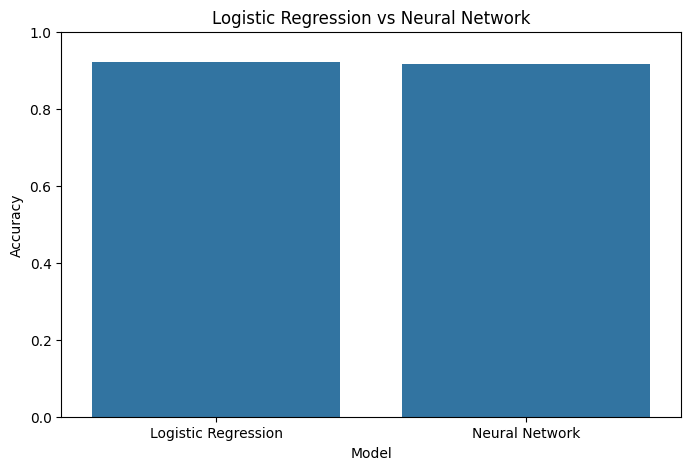

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.ylim(0, 1)

plt.title(
    "Logistic Regression vs Neural Network"
)

plt.ylabel("Accuracy")

plt.show()

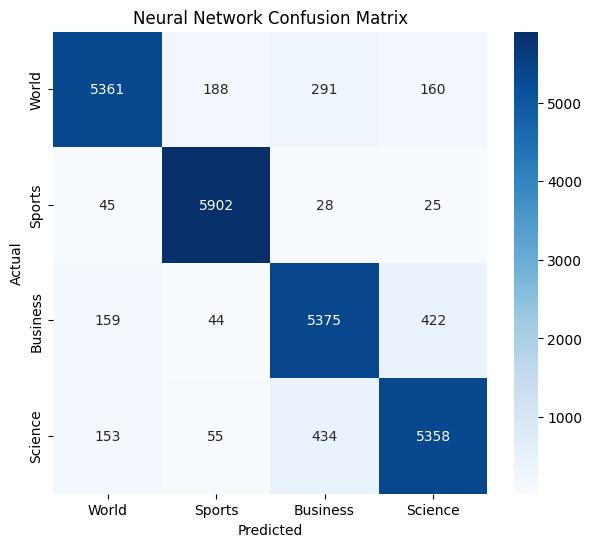

In [ ]:
nn_predictions = nn_model.predict(
    X_nn_val,
    verbose=0
)

nn_pred_classes = np.argmax(
    nn_predictions,
    axis=1
)

nn_cm = confusion_matrix(
    y_nn_val_zero,
    nn_pred_classes
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    nn_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'World',
        'Sports',
        'Business',
        'Science'
    ],
    yticklabels=[
        'World',
        'Sports',
        'Business',
        'Science'
    ]
)

plt.title(
    "Neural Network Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()